# Predecir el futuro

## Introducción

En esta sesión, aprenderemos a utilizar las librerias de `prophet` y `pmdarima` de Python para realizar análisis de series temporales de manera automatizada. A través de un caso práctico dentro de una empresa, comprenderemos cómo aplicar las librerias para predecir ventas futuras y tomar decisiones estratégicas basadas en datos.

## Objetivos de Aprendizaje

- Comprender los conceptos básicos del análisis de series temporales.
- Aprender a utilizar las librerías [`prophet`](https://facebook.github.io/prophet/) y [`pmdarima`](https://pypi.org/project/pmdarima/) para modelado automatizado de series temporales.
- Aplicar técnicas de predicción para resolver un problema empresarial real.
- Interpretar los resultados y extraer insights accionables.

---

## Caso Práctico: RazerTech Inc.

### Contexto de la Empresa

RazerTech Inc. es una empresa dedicada a la fabricación y venta de dispositivos electrónicos. A lo largo de los últimos tres años, ha experimentado fluctuaciones en sus ventas mensuales debido a factores estacionales y tendencias del mercado.

### Problema Empresarial

El departamento de finanzas necesita prever las ventas mensuales para el próximo año con el fin de:

- Optimizar la gestión del inventario.
- Planificar estrategias de marketing.
- Ajustar la producción y recursos.

### Objetivo de la Sesión

Utilizar las paqueterías de para crear un modelo que prediga las ventas mensuales de RazerTech Inc. para el próximo año, y proporcionar recomendaciones basadas en el análisis.

---

## Configuración del Entorno

Antes de comenzar, asegúrate de tener instaladas las siguientes librerías:

```bash
pip install pmdarima prophet

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from prophet import Prophet

## Paso 1: Importación de Librerías y Carga de Datos
Comenzamos importando las librerías necesarias y cargando el conjunto de datos proporcionado por la empresa.

In [35]:
df = pd.read_csv('data/ventas_mensuales.csv', parse_dates=['Fecha'])
df.head(10)

,Fecha,Ventas
0,2015-01-31,249.84
1,2015-02-28,239.75
2,2015-03-31,289.11
3,2015-04-30,329.54
4,2015-05-31,226.74
5,2015-06-30,355.10
6,2015-07-31,274.13
7,2015-08-31,218.60
8,2015-09-30,153.42
9,2015-10-31,214.08


## Paso 2: Exploración y Visualización de los Datos
Antes de modelar, es importante entender la naturaleza de nuestros datos.

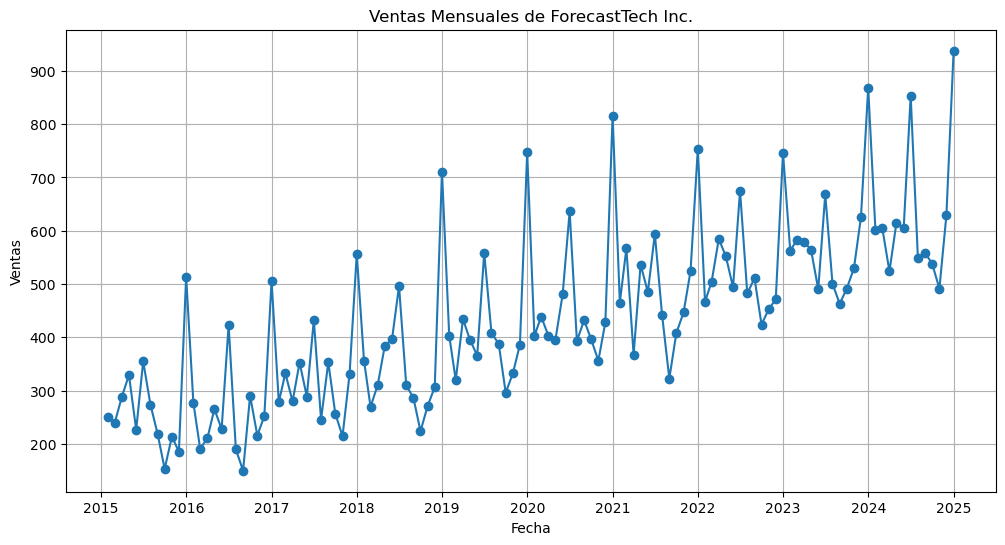

In [36]:
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'], df['Ventas'], marker='o')
plt.title('Ventas Mensuales de ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

## Paso 3: Configuración del Modelo
Las librerías se harán cargo del entrenamiento usando los datos.

### PMD ARIMA

In [37]:
df.head(10)

,Fecha,Ventas
0,2015-01-31,249.84
1,2015-02-28,239.75
2,2015-03-31,289.11
3,2015-04-30,329.54
4,2015-05-31,226.74
5,2015-06-30,355.10
6,2015-07-31,274.13
7,2015-08-31,218.60
8,2015-09-30,153.42
9,2015-10-31,214.08


In [38]:
df_autoarima = df.set_index('Fecha')
df_autoarima.head()

,Ventas
Fecha,
2015-01-31,249.84
2015-02-28,239.75
2015-03-31,289.11
2015-04-30,329.54
2015-05-31,226.74


In [39]:
train_size = int(len(df_autoarima)*0.8)
train_size

96

In [40]:
train, test = train_test_split(df_autoarima, train_size=train_size)

auto_arima_model = pm.auto_arima(train, seasonal=True, m=12)

In [41]:
forecasts = auto_arima_model.predict(test.shape[0])
forecasts

2023-01-31    546.414271
2023-02-28    538.803128
2023-03-31    530.041694
2023-04-30    557.751799
2023-05-31    522.761184
2023-06-30    680.075156
2023-07-31    508.184131
2023-08-31    496.721733
2023-09-30    467.640728
2023-10-31    476.299342
2023-11-30    524.101956
2023-12-31    816.987185
2024-01-31    558.306324
2024-02-29    563.012613
2024-03-31    557.890205
2024-04-30    592.824255
2024-05-31    564.705916
2024-06-30    712.012046
2024-07-31    539.205405
2024-08-31    528.020038
2024-09-30    500.795431
2024-10-31    511.442247
2024-11-30    558.006860
2024-12-31    848.419321
Freq: ME, dtype: float64

In [42]:
df['Fecha'][train_size:]

96    2023-01-31
97    2023-02-28
98    2023-03-31
99    2023-04-30
100   2023-05-31
101   2023-06-30
102   2023-07-31
103   2023-08-31
104   2023-09-30
105   2023-10-31
106   2023-11-30
107   2023-12-31
108   2024-01-31
109   2024-02-29
110   2024-03-31
111   2024-04-30
112   2024-05-31
113   2024-06-30
114   2024-07-31
115   2024-08-31
116   2024-09-30
117   2024-10-31
118   2024-11-30
119   2024-12-31
Name: Fecha, dtype: datetime64[ns]

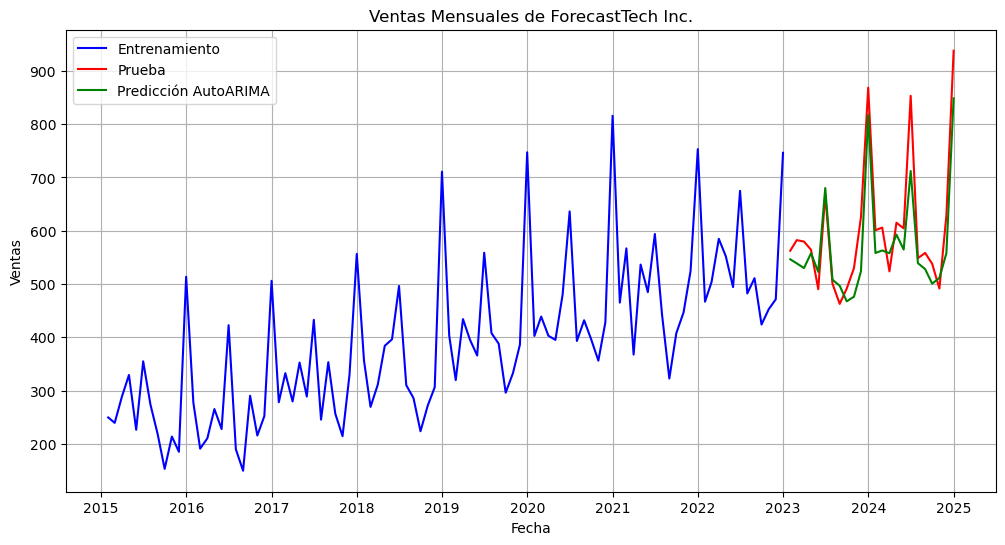

In [43]:
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'][:train_size], train, label='Entrenamiento', c='blue')
plt.plot(df['Fecha'][train_size:], test, label='Prueba', c='red')
plt.plot(df['Fecha'][train_size:], forecasts, label='Predicción AutoARIMA', c='green')
plt.title('Ventas Mensuales de ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

### Prophet

In [44]:
df_prophet = df.rename({'Fecha':'ds', 'Ventas':'y'}, axis=1)
df_prophet.iloc[:train_size]

,ds,y
0,2015-01-31,249.84
1,2015-02-28,239.75
2,2015-03-31,289.11
3,2015-04-30,329.54
4,2015-05-31,226.74
...,...,...
91,2022-08-31,511.01
92,2022-09-30,424.14
93,2022-10-31,452.92
94,2022-11-30,471.36


In [45]:
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

modelo_prophet = Prophet()
modelo_prophet.fit(train_prophet)

19:54:44 - cmdstanpy - INFO - Chain [1] start processing
19:54:44 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
future = modelo_prophet.make_future_dataframe(periods=len(test_prophet), freq='MS')
future # Solo son fechas

,ds
0,2015-01-31
1,2015-02-28
2,2015-03-31
3,2015-04-30
4,2015-05-31
...,...
115,2024-08-01
116,2024-09-01
117,2024-10-01
118,2024-11-01


In [47]:
forecast = modelo_prophet.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-31,222.163413,170.888689,272.219347
1,2015-02-28,188.475487,141.732571,238.310183
2,2015-03-31,254.364805,202.593717,306.030565
3,2015-04-30,267.983646,215.242011,317.827735
4,2015-05-31,203.229948,154.419794,253.234381
...,...,...,...,...
115,2024-08-01,451.888500,399.079010,495.648073
116,2024-09-01,460.390588,408.422859,509.326920
117,2024-10-01,672.089142,624.932836,719.841787
118,2024-11-01,476.506765,423.596376,528.876394


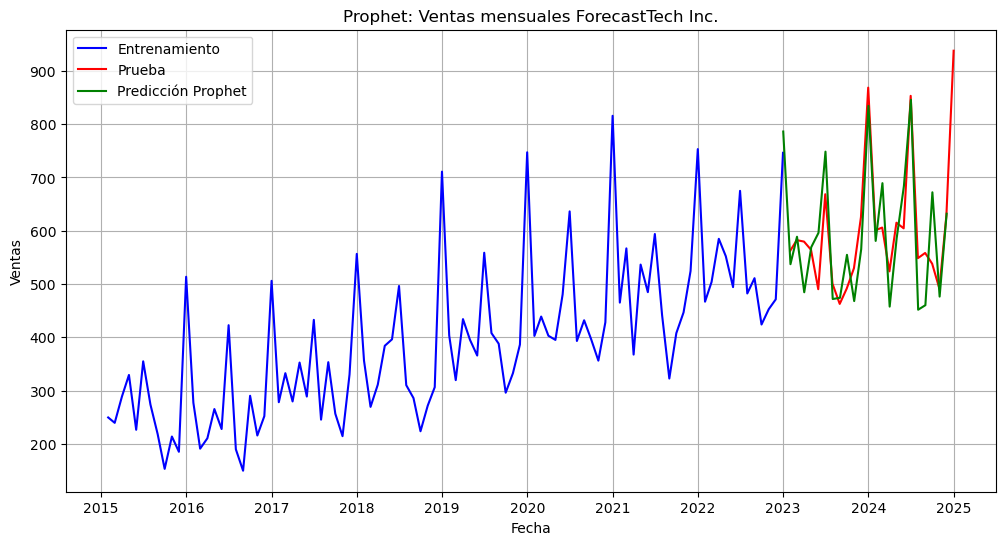

In [48]:
forecast_train = forecast.iloc[:train_size]
forecast_test = forecast.iloc[train_size:]

plt.figure(figsize=(12,6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Entrenamiento', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Prueba', color='red')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predicción Prophet', color='green')
plt.title('Prophet: Ventas mensuales ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


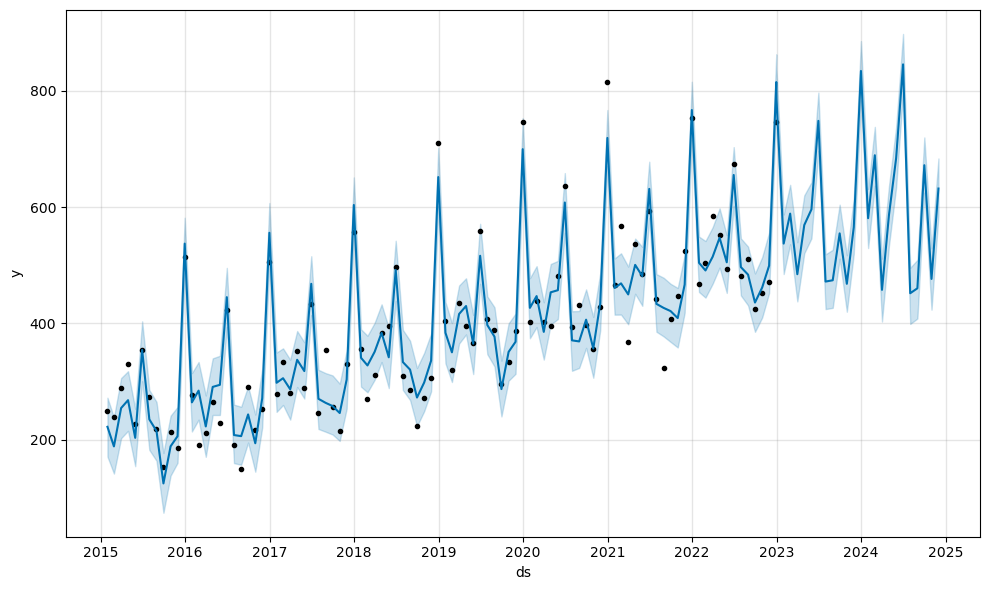

In [49]:
fig1 = modelo_prophet.plot(forecast)

## Paso 4: Evaluación del Modelo
Predicción y Comparación con Datos Reales

Para saber qué tan bien está funcionando nuestro modelo, debemos comparar las predicciones con los valores reales del conjunto de prueba (en el caso de pmdarima) o con los datos observados recientes (en el caso de prophet).

### Evaluación del modelo auto_arima
Calculamos el Error Absoluto Medio (MAE) y el Error Cuadrático Medio (RMSE).

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_arima = mean_absolute_error(test, forecasts) # mean(absolute(real - predicted))
rmse_arima = np.sqrt(mean_squared_error(test, forecasts)) # mean(root((real - predicted)**2))

print(f"MAE (Auto-ARIMA): {mae_arima:.2f}")
print(f"RMSE (Auto-ARIMA): {rmse_arima:.2f}")


MAE (Auto-ARIMA): 42.13
RMSE (Auto-ARIMA): 52.43


### Evaluación del modelo prophet
Para evaluar prophet, comparamos las predicciones en el periodo de testeo contra los valores reales, si existen. Alternativamente, si solo queremos evaluar visualmente:

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_62686/768907543.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


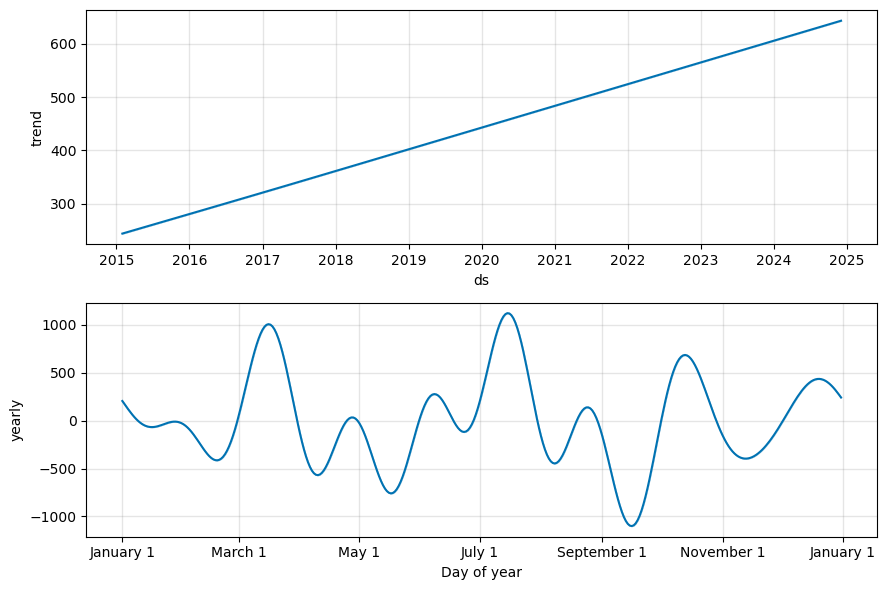

In [51]:
from prophet.plot import plot_components_plotly

fig2 = modelo_prophet.plot_components(forecast)
fig2.show()

También podemos calcular métricas si comparamos el yhat con los valores reales en el periodo reciente:

In [32]:
forecast['ds'] = pd.to_datetime(forecast['ds']).dt.to_period('M').dt.to_timestamp() + pd.offsets.MonthEnd(0)
forecast['ds']

real_vs_pred = df_prophet.merge(forecast[['ds', 'yhat']], on='ds', how='left')
valid = real_vs_pred[-24:]

mae_prophet = mean_absolute_error(valid['y'], valid['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(valid['y'], valid['yhat']))

print(f"MAE (Prophet): {mae_prophet:.2f}")
print(f"RMSE (Prophet): {rmse_prophet:.2f}")


MAE (Prophet): 131.52
RMSE (Prophet): 163.26


## Paso 5: Predicción Futura

Una vez evaluado el modelo, lo utilizamos para hacer predicciones de los próximos 12 meses.

### Con auto_arima

/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(0,1,1)(2,0,2)[12]           (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/arima.py", line 603, in fit
    self._fit(y, X, **fit_args)
  File "/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/arima.py", line 524, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/arima.py", line 510, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py", line 703, in fit
    mlef

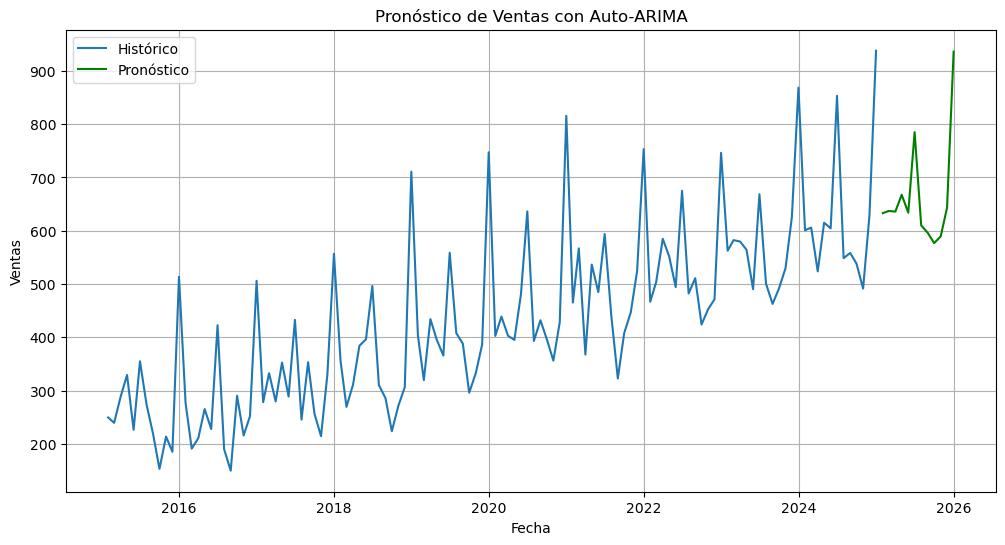

In [33]:
n_months = 12
auto_arima_model = pm.auto_arima(df_autoarima, seasonal=True, m=12)
future_forecasts_arima = auto_arima_model.predict(n_periods=n_months)

future_dates = pd.date_range(start=df_autoarima.index[-1] + pd.DateOffset(months=1), periods=n_months, freq='MS')
forecast_df_arima = pd.DataFrame({'Fecha': future_dates, 'Predicción': future_forecasts_arima})

plt.figure(figsize=(12,6))
plt.plot(df_autoarima.index, df_autoarima['Ventas'], label='Histórico')
plt.plot(forecast_df_arima['Fecha'], forecast_df_arima['Predicción'], label='Pronóstico', color='green')
plt.title('Pronóstico de Ventas con Auto-ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


### Con prophet

Ya generamos forecast con 12 periodos futuros. Solo visualizamos los valores proyectados:

14:08:24 - cmdstanpy - INFO - Chain [1] start processing
14:08:24 - cmdstanpy - INFO - Chain [1] done processing


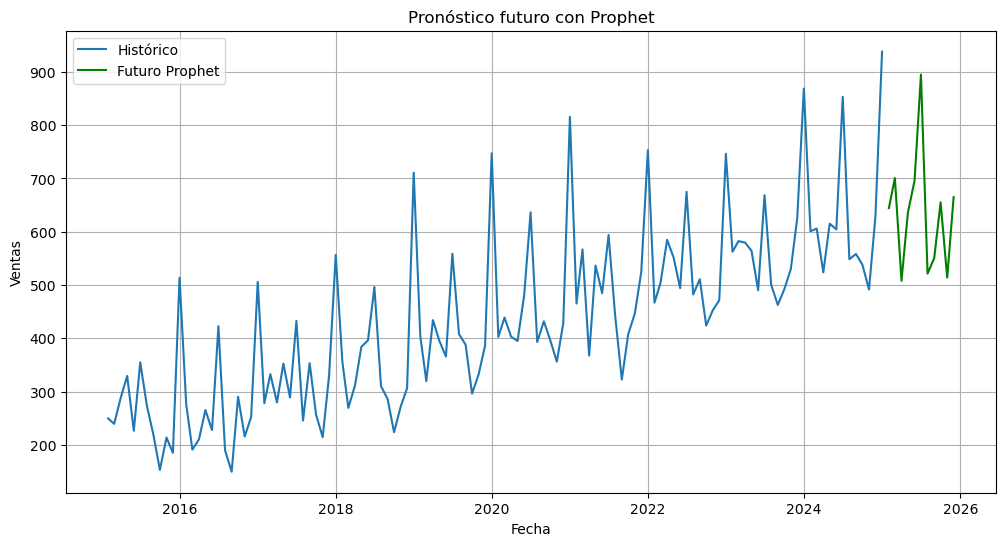

In [ ]:
df_prophet = df.rename({'Fecha':'ds', 'Ventas':'y'}, axis=1)

modelo_prophet = Prophet()
modelo_prophet.fit(df_prophet)

future_prophet = modelo_prophet.make_future_dataframe(periods=n_months, freq='MS')
forecast_future = modelo_prophet.predict(future_prophet)
forecast_12meses = forecast_future.tail(n_months-1)

plt.figure(figsize=(12,6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Histórico')
plt.plot(forecast_12meses['ds'], forecast_12meses['yhat'], label='Futuro Prophet', color='green')
plt.title('Pronóstico futuro con Prophet')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión y Recomendaciones Estratégicas
Una vez obtenidas las predicciones:

- Inventario: Aumentar producción en los meses con mayor demanda proyectada.

- Marketing: Realizar campañas específicas en los meses con ventas más bajas para compensar la caída.

- Finanzas: Ajustar flujo de efectivo y recursos de personal para meses clave.

